### TOA spectra under various RT configurations
Figure S5 in supinfo

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [16]:
data_dir = '/home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/'
no_aerosols = xr.open_dataset(os.path.join(data_dir, 'toa_siflib1_peak0p3_678p0nm_ws5p0_wctrue_wc0p22_noaerosol.nc'))
high_aerosols = xr.open_dataset(os.path.join(data_dir, 'toa_col001_siflib1_peak0p3_678p0nm_ws5p0_wctrue_wc0p22.nc'))

# wavelength
wvlen_lres = no_aerosols.wavelength_oci.values
wvlen_hres = no_aerosols.wavelength_hres.values


viewing geometry: sza= 30 vza= 30.0 vaz= 0.0


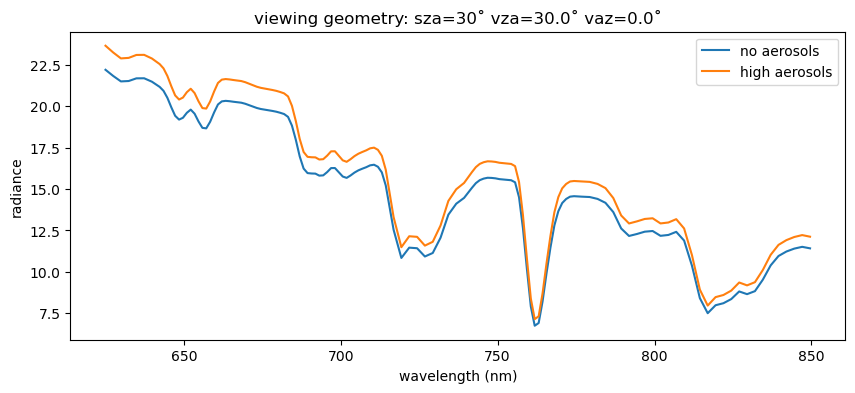

In [ ]:
sza = 30
view_index = 6  # set to 6 for glint spot
vza = no_aerosols.vza.values
vaz = no_aerosols.vaz.values
print("viewing geometry: sza=", sza, "vza=", vza[view_index], "vaz=", vaz[view_index])

pol = 0   # Stokes I

# select radiance
rad_no_aerosols = no_aerosols.radiance_oci.isel(view=view_index, pol=pol).values
rad_high_aerosols = high_aerosols.radiance_oci.isel(view=view_index, pol=pol).values

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wvlen_lres, rad_no_aerosols, label='no aerosols')
ax.plot(wvlen_lres, rad_high_aerosols, label='high aerosols')
ax.set_title("viewing geometry: sza=" + str(sza) + "˚ vza=" + str(vza[view_index]) + "˚ vaz=" + str(vaz[view_index]) + "˚")
ax.legend()
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('radiance')
plt.show()



Text(0.5, 1.0, 'ratio between w/ and w/o aerosols')

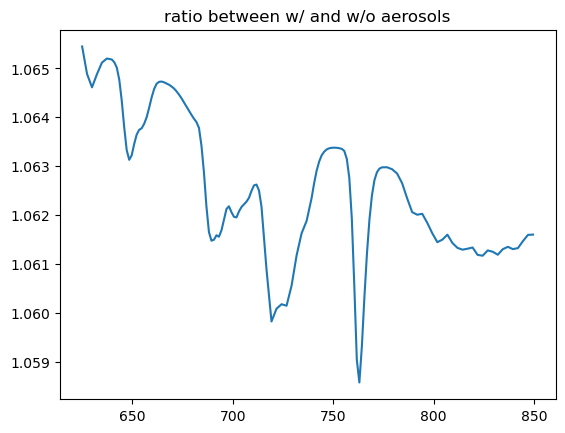

In [28]:
plt.plot(wvlen_lres, rad_high_aerosols/rad_no_aerosols, label='ratio')
plt.title("ratio between w/ and w/o aerosols")

vza1= 45.0
vza and vaz  15.0 180.0


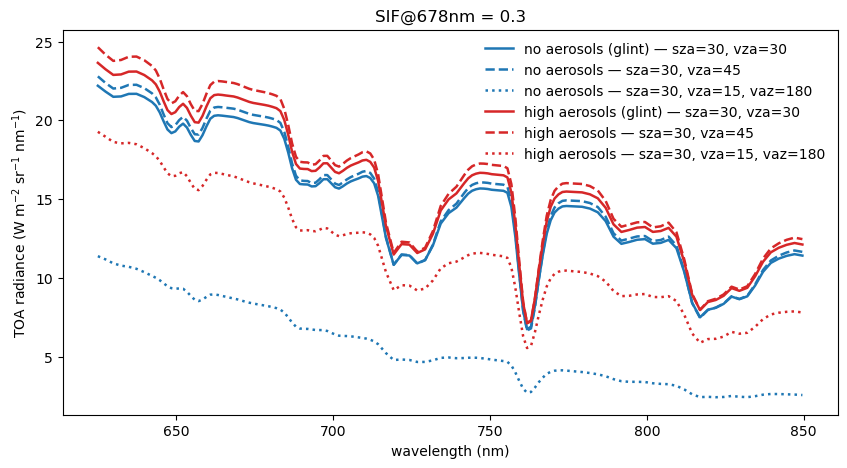

In [42]:
# viewing geometry: color = aerosol case, linestyle = VZA
rad_no_aerosols_vza1 = no_aerosols.radiance_oci.isel(view=view_index+1, pol=pol).values
rad_high_aerosols_vza1 = high_aerosols.radiance_oci.isel(view=view_index+1, pol=pol).values
print("vza1=", vza[view_index+1])

rad_no_aerosols_vza2 = no_aerosols.radiance_oci.isel(view=view_index-3, pol=pol).values
rad_high_aerosols_vza2 = high_aerosols.radiance_oci.isel(view=view_index-3, pol=pol).values
print("vza and vaz ", vza[view_index-3], vaz[view_index-3])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wvlen_lres, rad_no_aerosols, color='C0', ls='-', lw=1.8,
        label='no aerosols (glint) — sza=30, vza=30')
ax.plot(wvlen_lres, rad_no_aerosols_vza1, color='C0', ls='--', lw=1.8,
        label='no aerosols — sza=30, vza=45')
ax.plot(wvlen_lres, rad_no_aerosols_vza2, color='C0', ls=':', lw=1.8,
        label='no aerosols — sza=30, vza=15, vaz=180')
ax.plot(wvlen_lres, rad_high_aerosols, color='C3', ls='-', lw=1.8,
        label='high aerosols (glint) — sza=30, vza=30')
ax.plot(wvlen_lres, rad_high_aerosols_vza1, color='C3', ls='--', lw=1.8,
        label='high aerosols — sza=30, vza=45')
ax.plot(wvlen_lres, rad_high_aerosols_vza2, color='C3', ls=':', lw=1.8,
        label='high aerosols — sza=30, vza=15, vaz=180')
ax.legend(frameon=False)
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('TOA radiance (W m$^{-2}$ sr$^{-1}$ nm$^{-1}$)')
ax.set_title("SIF@678nm = 0.3")
plt.show()
